In [1]:
from pydantic import BaseModel , Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from typing import Literal, Dict , Any, Annotated, List
from IPython.display import Image, display 
import instructor
from operator import add

import random
import ast
import inspect
import json

from openai import OpenAI
from jinja2 import Template

from utils.utils import get_tool_descriptions, format_ai_message


/home/nurda/ai-engineering/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Single node graph

In [4]:
class State(BaseModel):
    message : str
    answer : str= ""
    vibe: str

In [ ]:
def append_vibe_to_query(state: State) -> dict:
    return {
        "answer":f"{state.message} {state.vibe}"
    }


In [7]:
workflow = StateGraph(State)
workflow.add_node(
    "append_vibe_to_query",
    append_vibe_to_query,
)

workflow.add_edge(START, "append_vibe_to_query")
workflow.add_edge("append_vibe_to_query", END)

graph = workflow.compile()


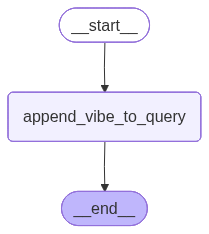

In [10]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
inital_state = {
    "message": "What is the weather like today?",
    "vibe": "in a happy tone"
}

In [12]:
result = graph.invoke(inital_state)

In [13]:
result

{'message': 'What is the weather like today?',
 'answer': 'What is the weather like today? in a happy tone',
 'vibe': 'in a happy tone'}

### Conditional Graph

In [15]:
class State(BaseModel):
    message : str
    answer : str= ""

In [19]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer":f"I'm here to add some vibes:"
    }


In [16]:
def router(state: State) -> Literal["append_vibe_1", "append_vibe_2", "append_vibe_3"]:
    vibes = ["append_vibe_1", "append_vibe_2", "append_vibe_3"]
    vibe_path = random.choice(vibes)
    return vibe_path

In [17]:
def append_vibe_1(state: State) -> dict:
    vibe = "I'm feeeling happy today!"
    return {
        "answer":f"{state.answer} {vibe}"
    }


def append_vibe_2(state: State) -> dict:
    vibe = "I'm feeeling like a boss today!"
    return {
        "answer":f"{state.answer} {vibe}"
    }


def append_vibe_3(state: State) -> dict:
    vibe = "I'm feeeling like a baddas today!"
    return {
        "answer":f"{state.answer} {vibe}"
    }

In [20]:
workflow = StateGraph(State)

workflow.add_node(
    "append_vibes_to_query",
    append_vibes_to_query,
)

workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)


workflow.add_conditional_edges(
    "append_vibes_to_query",
    router,
    {
        "append_vibe_1": "append_vibe_1",
        "append_vibe_2": "append_vibe_2",
        "append_vibe_3": "append_vibe_3",
    }
)

workflow.add_edge(START, "append_vibes_to_query")


workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()


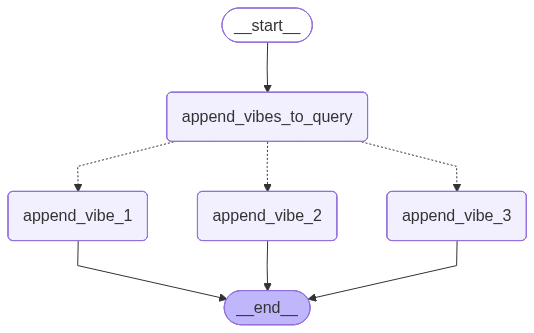

In [21]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
inital_state = {
    "message": "Give me some vibes!",  
}

In [23]:
result = graph.invoke(inital_state)

In [24]:
result

{'message': 'Give me some vibes!',
 'answer': "I'm here to add some vibes: I'm feeeling like a baddas today!"}

## Agent graph


In [2]:
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """

    return f"{query} {vibe}"

In [3]:
get_tool_descriptions([append_vibes])

[{'name': 'append_vibes',
  'description': 'Takes in a query and a vibe and returns a string with the query and vibe appended.',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'The query to append the vibe to.'},
    'vibe': {'type': 'string',
     'description': 'The vibe to append to the query.'}}},
  'required': ['query', 'vibe'],
  'returns': {'type': 'string',
   'description': 'A string with the query and vibe appended.'}}]

In [4]:
class ToolCall(BaseModel):
    name : str
    arguments : dict

In [5]:
class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ''
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [6]:
from openai import OpenAI

client_local = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",  
)

In [7]:
from api.agents.local_models import CHAT_MODEL , EMBED_MODEL


In [8]:
class AgentResponse(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = Field(default_factory=list)

In [ ]:
def agent_node(state: State) -> dict:

    prompt_template = """You are a assistant that is generating vibes for a user.

You will be given a selection of tools you can use to add vibes to a user's query.

<Available tools>
{{ available_tools | tojson }}
</Available tools>

When you need to use a tool, format your response as:

<tool_call>
{"name": "tool_name", "arguments": {...}}
</tool_call>

Instructions:
- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.
"""

    template = Template(prompt_template)

    prompt = template.render(
        available_tools=state.available_tools
    )

    client = instructor.from_openai(client_local)

    response, raw_response = client.chat.completions.create_with_completion(
        model=CHAT_MODEL,
        response_model=AgentResponse,
        messages=[{"role": "system", "content": prompt}, {"role": "user", "content": state.message}],
        temperature=0.5,
    )


    ai_message = format_ai_message(response)

    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls
    }

# Short explainer on message types and formatting


In [10]:
conversation = [
    {'role': 'user', 'content': 'Give me some vibes!'},
    {'role': 'assistant', 'content': 'I am here to add some vibes:'},
    {'role': 'user', 'content': 'I am feeling like a badass today!'}
]

In [11]:
convert_to_messages(conversation)

[HumanMessage(content='Give me some vibes!', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am here to add some vibes:', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I am feeling like a badass today!', additional_kwargs={}, response_metadata={})]

In [12]:
convert_to_openai_messages(convert_to_messages(conversation))

[{'role': 'user', 'content': 'Give me some vibes!'},
 {'role': 'assistant', 'content': 'I am here to add some vibes:'},
 {'role': 'user', 'content': 'I am feeling like a badass today!'}]

In [29]:
dummy_response = AgentResponse(answer = "I'm here to add some vibes",
                                tool_calls=[ToolCall(name="append_vibes", arguments={"query": "Give me some vibes!", "vibe": "in a happy tone"})])

In [30]:
dummy_response

AgentResponse(answer="I'm here to add some vibes", tool_calls=[ToolCall(name='append_vibes', arguments={'query': 'Give me some vibes!', 'vibe': 'in a happy tone'})])

In [31]:
format_ai_message(dummy_response)

AIMessage(content="I'm here to add some vibes", additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'in a happy tone'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])

### End of formatting messages

In [11]:
def tool_router(state: State) -> str:
    """Decide whether to continue or end"""

    if len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [12]:
workflow = StateGraph[State, None, State, State](State)

tools = [append_vibes]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)

workflow.add_edge(START, "agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", END)

graph = workflow.compile()

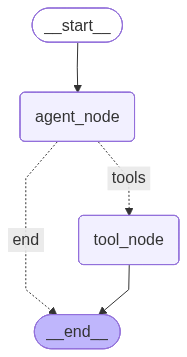

In [13]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
inital_state = {
    "message": "Give me some vibes!",  
    "available_tools": tool_descriptions
}

In [16]:
result = graph.invoke(inital_state)

InstructorRetryException: <failed_attempts>

<generation number="1">
<exception>
    Instructor does not support multiple tool calls, use List[Model] instead
</exception>
<completion>
    ChatCompletion(id='chatcmpl-748', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None))], created=1777042534, model='qwen2.5:7b', object='chat.completion', service_tier=None, system_fingerprint='fp_ollama', usage=CompletionUsage(completion_tokens=33, prompt_tokens=428, total_tokens=461, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=None), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))
</completion>
</generation>

<generation number="2">
<exception>
    Instructor does not support multiple tool calls, use List[Model] instead
</

In [ ]:
result